In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('Churn_Modelling.csv')

In [3]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,3,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,4,15701354,Boni,699,France,Female,39.0,1,0.00,2,0.0,0.0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,NaN,1.0,79084.10,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10002 entries, 0 to 10001
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10002 non-null  int64  
 1   CustomerId       10002 non-null  int64  
 2   Surname          10002 non-null  object 
 3   CreditScore      10002 non-null  int64  
 4   Geography        10001 non-null  object 
 5   Gender           10002 non-null  object 
 6   Age              10001 non-null  float64
 7   Tenure           10002 non-null  int64  
 8   Balance          10002 non-null  float64
 9   NumOfProducts    10002 non-null  int64  
 10  HasCrCard        10001 non-null  float64
 11  IsActiveMember   10001 non-null  float64
 12  EstimatedSalary  10002 non-null  float64
 13  Exited           10002 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 1.1+ MB


In [5]:
data.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          1
Gender             0
Age                1
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          1
IsActiveMember     1
EstimatedSalary    0
Exited             0
dtype: int64

In [6]:
data.dropna(inplace=True)

In [7]:
data.duplicated().sum()

np.int64(2)

In [8]:
data.drop_duplicates(inplace=True)

In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
print(data.describe(include='O'))

       Surname Geography Gender
count     9996      9996   9996
unique    2932         3      2
top      Smith    France   Male
freq        32      5011   5454


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9996 entries, 0 to 10000
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        9996 non-null   int64  
 1   CustomerId       9996 non-null   int64  
 2   Surname          9996 non-null   object 
 3   CreditScore      9996 non-null   int64  
 4   Geography        9996 non-null   object 
 5   Gender           9996 non-null   object 
 6   Age              9996 non-null   float64
 7   Tenure           9996 non-null   int64  
 8   Balance          9996 non-null   float64
 9   NumOfProducts    9996 non-null   int64  
 10  HasCrCard        9996 non-null   float64
 11  IsActiveMember   9996 non-null   float64
 12  EstimatedSalary  9996 non-null   float64
 13  Exited           9996 non-null   int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 1.1+ MB


In [12]:
data = data.drop(columns='RowNumber')

In [13]:
num_col = data.select_dtypes(include=["float64","int64"])
num_col

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,619,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,15647311,608,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,15619304,502,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,15701354,699,39.0,1,0.00,2,0.0,0.0,93826.63,0
5,15574012,645,44.0,8,113755.78,2,1.0,0.0,149756.71,1
...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,39.0,5,0.00,2,1.0,0.0,96270.64,0
9996,15569892,516,35.0,10,57369.61,1,1.0,1.0,101699.77,0
9997,15584532,709,36.0,7,0.00,1,0.0,1.0,42085.58,1
9998,15682355,772,42.0,3,75075.31,2,1.0,0.0,92888.52,1


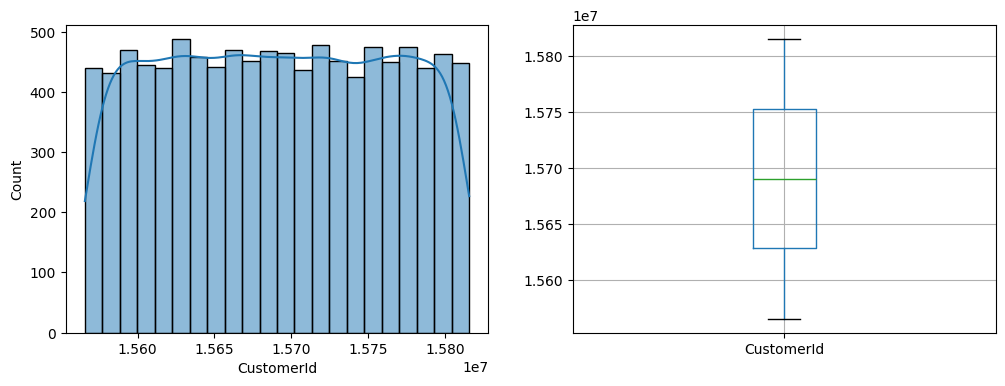

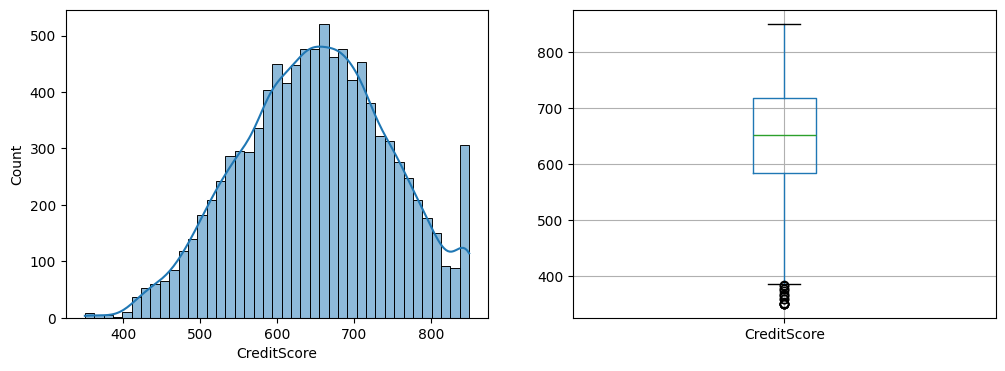

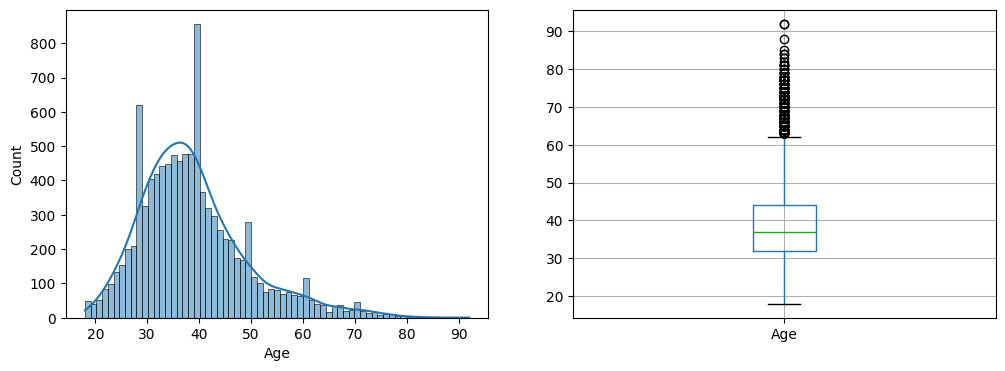

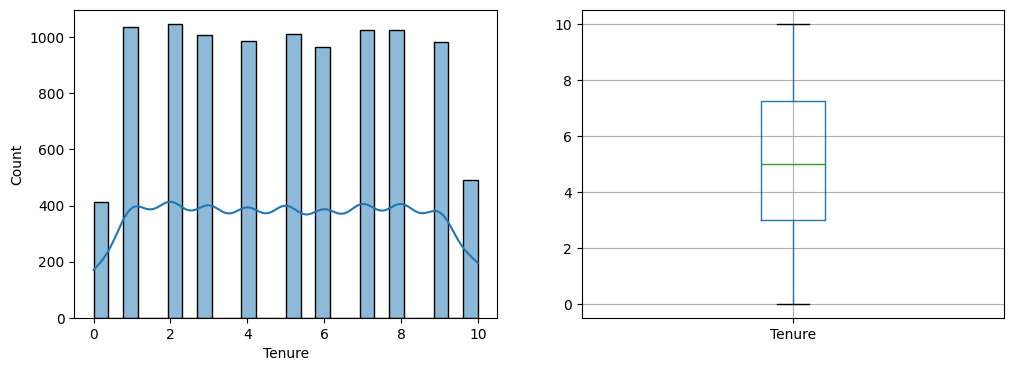

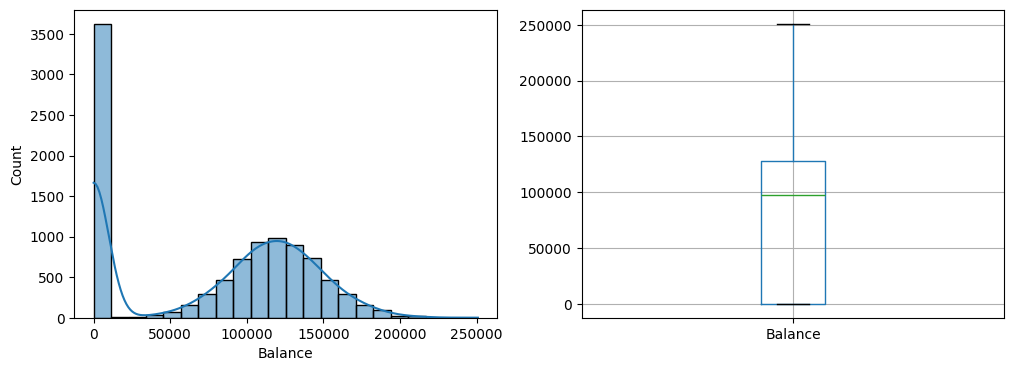

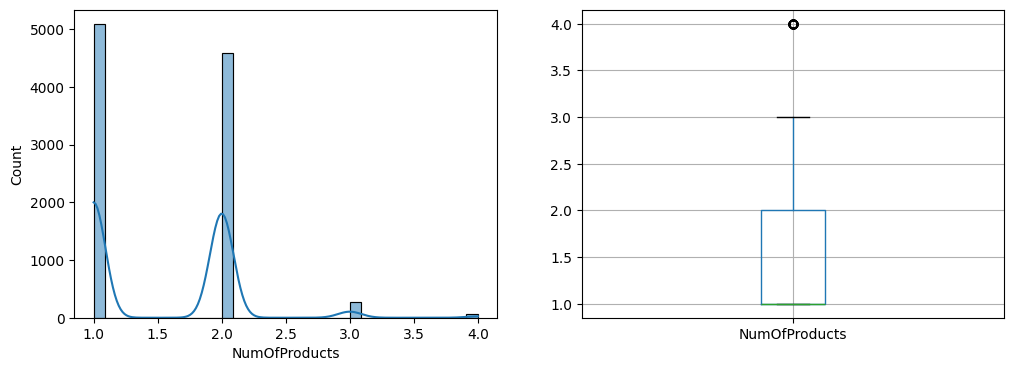

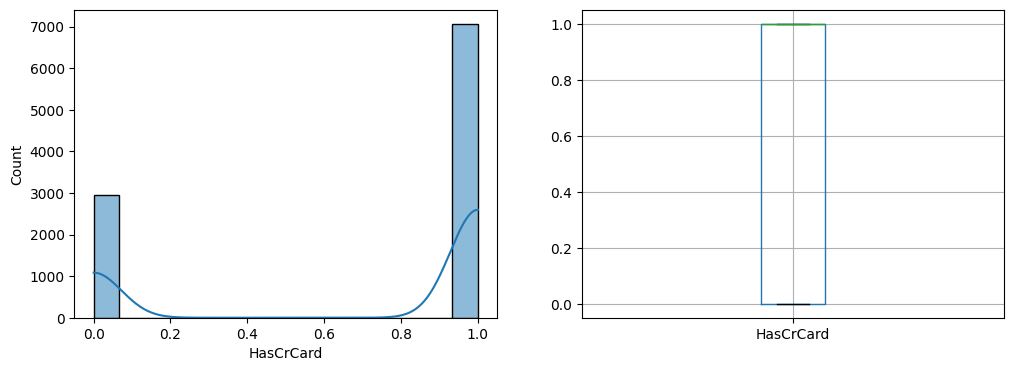

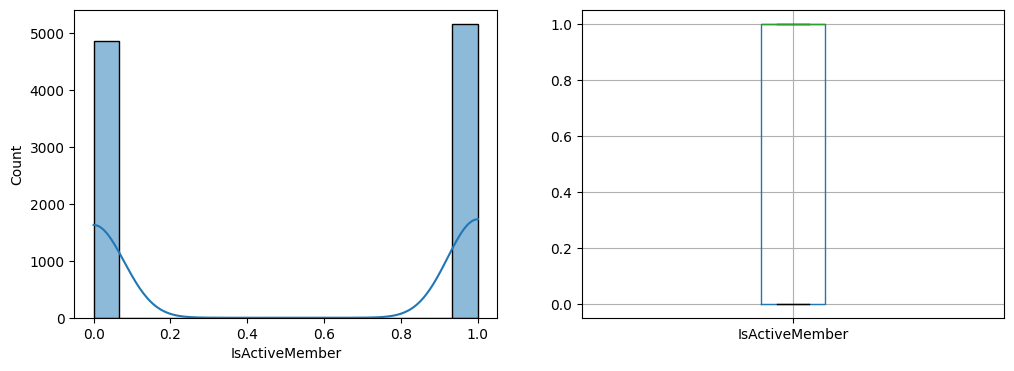

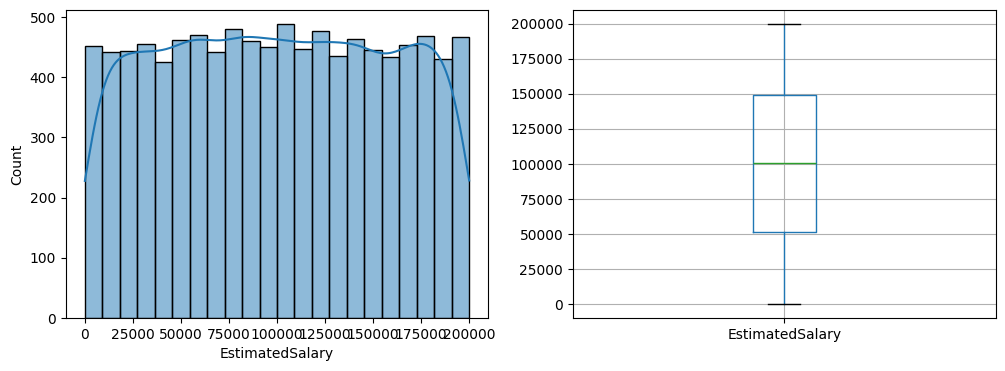

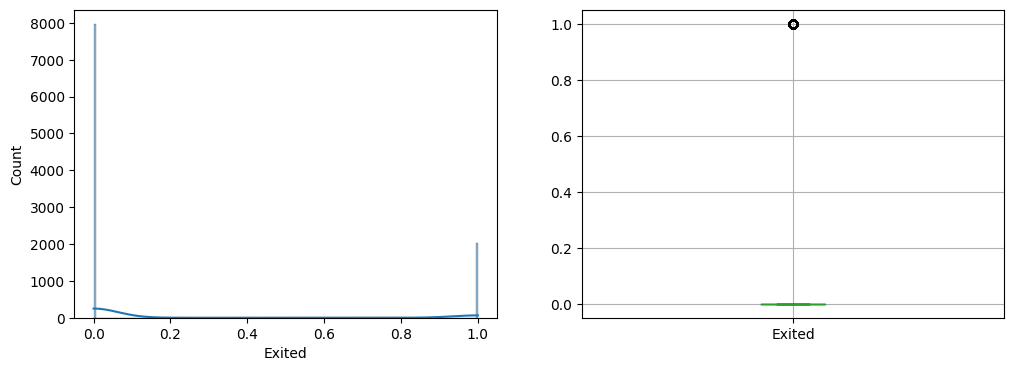

In [14]:
for c in num_col:
    fig, ax = plt.subplots(1,2, figsize=(12,4))

    sns.histplot(data[c], kde=True, ax=ax[0])
    data.boxplot(column=c, ax=ax[1])

    plt.show()

In [15]:
data.columns


Index(['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited'],
      dtype='object')

In [16]:
data_clean = data.drop(columns='CustomerId')

In [17]:
data_clean.columns

Index(['Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited'],
      dtype='object')

In [18]:
data_clean.describe(include='O')

,Surname,Geography,Gender
count,9996,9996,9996
unique,2932,3,2
top,Smith,France,Male
freq,32,5011,5454


In [19]:
data_clean['Surname']

0         Hargrave
1             Hill
2             Onio
3             Boni
5              Chu
           ...    
9995      Obijiaku
9996     Johnstone
9997           Liu
9998     Sabbatini
10000       Walker
Name: Surname, Length: 9996, dtype: object

In [20]:
data_clean = data_clean.drop(columns='Surname')

In [21]:
data_clean.describe(include='O')

,Geography,Gender
count,9996,9996
unique,3,2
top,France,Male
freq,5011,5454


In [22]:
data_clean.info()


<class 'pandas.core.frame.DataFrame'>
Index: 9996 entries, 0 to 10000
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      9996 non-null   int64  
 1   Geography        9996 non-null   object 
 2   Gender           9996 non-null   object 
 3   Age              9996 non-null   float64
 4   Tenure           9996 non-null   int64  
 5   Balance          9996 non-null   float64
 6   NumOfProducts    9996 non-null   int64  
 7   HasCrCard        9996 non-null   float64
 8   IsActiveMember   9996 non-null   float64
 9   EstimatedSalary  9996 non-null   float64
 10  Exited           9996 non-null   int64  
dtypes: float64(5), int64(4), object(2)
memory usage: 937.1+ KB


In [23]:
# from sklearn.preprocessing import OneHotEncoder

# ohe = OneHotEncoder()
# col = ['Geography', 'Gender']
# data_encoded = ohe.fit_transform(data_clean[col])
# data_encoded.toarray()
# data_encoded_df = pd.DataFrame(data_encoded.toarray(), columns=ohe.get_feature_names_out(col))

# data_encoded_df.head()
# data_encoded_df.info()
# data_clean = data_clean.drop(columns=col)
# data_clean.info()
# data_final = pd.concat([data_clean, data_encoded_df], axis=1)
# data_final.info()

In [24]:
data_clean.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

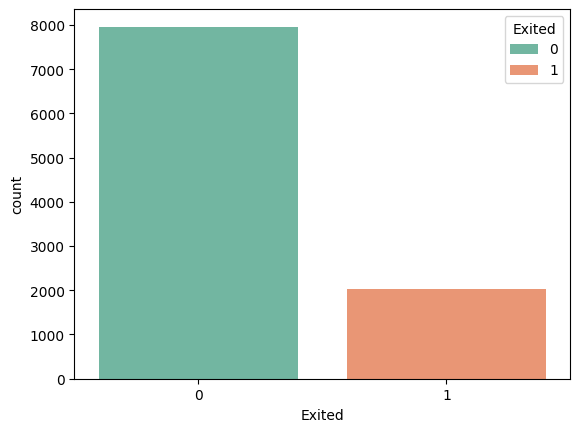

In [25]:
sns.countplot(x='Exited', data=data_clean, palette='Set2' , hue='Exited')
plt.show()

In [26]:
from sklearn.model_selection import train_test_split
X = data_clean.drop(columns='Exited')
y = data_clean['Exited']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [27]:
X_train.shape, y_train.shape

((7996, 10), (7996,))

In [28]:
cat_cols = ["Gender","Geography"]
num_col = X_train.drop(columns= cat_cols).columns

### OneHot encoder

In [29]:
# OneHot Encoder
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop="first" ,handle_unknown="ignore", sparse_output= False)

X_train_cat = ohe.fit_transform(X_train[cat_cols])
X_test_cat = ohe.transform(X_test[cat_cols])


In [30]:
cat_columns = ohe.get_feature_names_out(cat_cols)
cat_columns

array(['Gender_Male', 'Geography_Germany', 'Geography_Spain'],
      dtype=object)

### Scaling

In [31]:
X_train_cat = pd.DataFrame(X_train_cat, columns=cat_columns, index=X_train.index)
X_test_cat = pd.DataFrame(X_test_cat, columns=cat_columns, index=X_test.index)

In [32]:
X_test_cat

,Gender_Male,Geography_Germany,Geography_Spain
1082,1.0,0.0,1.0
4340,0.0,0.0,1.0
8970,1.0,0.0,1.0
5460,1.0,1.0,0.0
2411,0.0,1.0,0.0
...,...,...,...
1099,1.0,0.0,1.0
3115,1.0,0.0,0.0
4196,0.0,0.0,1.0
1565,1.0,0.0,0.0


In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[num_col])
X_test_num = scaler.transform(X_test[num_col])

In [34]:
num_col

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary'],
      dtype='object')

In [35]:
X_train_num = pd.DataFrame(X_train_num, columns=num_col, index=X_train.index)
X_test_num= pd.DataFrame(X_test_num , columns=num_col , index=X_test.index)

### combine

In [36]:
X_train_processed = pd.concat([X_train_cat,X_train_num],axis=1)
X_test_processed = pd.concat([X_test_cat,X_test_num],axis=1)

In [37]:
X_train_processed.shape

(7996, 11)

In [38]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7996 entries, 4851 to 7274
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      7996 non-null   int64  
 1   Geography        7996 non-null   object 
 2   Gender           7996 non-null   object 
 3   Age              7996 non-null   float64
 4   Tenure           7996 non-null   int64  
 5   Balance          7996 non-null   float64
 6   NumOfProducts    7996 non-null   int64  
 7   HasCrCard        7996 non-null   float64
 8   IsActiveMember   7996 non-null   float64
 9   EstimatedSalary  7996 non-null   float64
dtypes: float64(5), int64(3), object(2)
memory usage: 687.2+ KB


In [39]:
X_train_processed.columns

Index(['Gender_Male', 'Geography_Germany', 'Geography_Spain', 'CreditScore',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary'],
      dtype='object')

## Buliding models

## Logistic Regression

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay

lr_model = LogisticRegression(random_state=42, max_iter=1000)

lr_model.fit(X_train_processed,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [41]:
y_pred = lr_model.predict(X_test_processed)
y_proba = lr_model.predict_proba(X_test_processed)[:,1]

In [42]:
acc = accuracy_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
roc = roc_auc_score(y_test,y_proba)

print('Logistic Regression metrics :')
print(f"Accuracy:{acc:.4f}, F1 Score : {f1:.4f}, ROC-AUC : {roc:.4f}")

Logistic Regression metrics :
Accuracy:0.8035, F1 Score : 0.2815, ROC-AUC : 0.7612


In [43]:
print("Confusion Matrix")
print(confusion_matrix(y_test,y_pred))
print("Classification Report")
print(classification_report(y_test,y_pred))

Confusion Matrix
[[1530   61]
 [ 332   77]]
Classification Report
              precision    recall  f1-score   support

           0       0.82      0.96      0.89      1591
           1       0.56      0.19      0.28       409

    accuracy                           0.80      2000
   macro avg       0.69      0.57      0.58      2000
weighted avg       0.77      0.80      0.76      2000



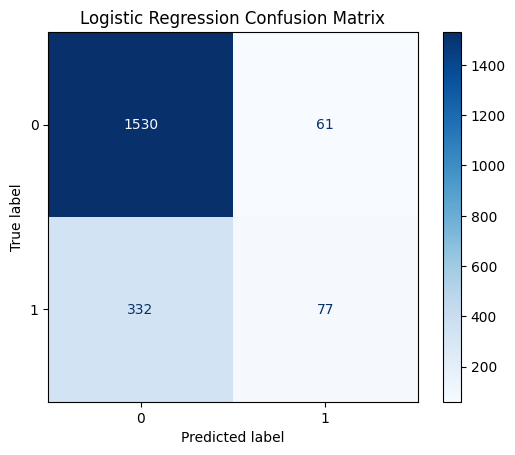

In [44]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap=plt.cm.Blues)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

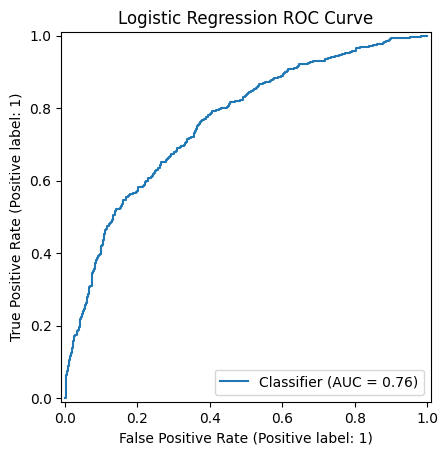

In [45]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Logistic Regression ROC Curve")
plt.show()

##  K-Nearest Neighbors (KNN)

In [46]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_processed,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [47]:
y_pred = knn.predict(X_test_processed)
y_proba = knn.predict_proba(X_test_processed)[:,1]

In [48]:
acc = accuracy_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
roc = roc_auc_score(y_test,y_proba)

print("KNN Metrics")
print(f"Accuracy : {acc:.4f}, F1 : {f1:.4f}, ROC-AUC : {roc:.4f}")


KNN Metrics
Accuracy : 0.8380, F1 : 0.5091, ROC-AUC : 0.7900


In [49]:
print("Confusion Matrix")
print(confusion_matrix(y_test,y_pred))
print("Classification Report")
print(classification_report(y_test,y_pred))

Confusion Matrix
[[1508   83]
 [ 241  168]]
Classification Report
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      1591
           1       0.67      0.41      0.51       409

    accuracy                           0.84      2000
   macro avg       0.77      0.68      0.71      2000
weighted avg       0.82      0.84      0.82      2000



## Support Vector Machine (SVM)

In [50]:
from sklearn.svm import SVC
svm = SVC(probability=True,kernel='rbf',C=1.0, random_state=42)

svm.fit(X_train_processed,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [51]:
y_pred =svm.predict(X_test_processed)
y_proba =svm.predict_proba(X_test_processed)[:,1]

In [52]:
acc = accuracy_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
roc = roc_auc_score(y_test,y_proba)

print("svm Metrics")
print(f"Accuracy : {acc:.4f}, F1 : {f1:.4f}, ROC-AUC : {roc:.4f}")

svm Metrics
Accuracy : 0.8520, F1 : 0.5148, ROC-AUC : 0.8235


In [53]:
print("Confusion Matrix")
print(confusion_matrix(y_test,y_pred))
print("Classification Report")
print(classification_report(y_test,y_pred))

Confusion Matrix
[[1547   44]
 [ 252  157]]
Classification Report
              precision    recall  f1-score   support

           0       0.86      0.97      0.91      1591
           1       0.78      0.38      0.51       409

    accuracy                           0.85      2000
   macro avg       0.82      0.68      0.71      2000
weighted avg       0.84      0.85      0.83      2000



### Decision Tree 

In [54]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42 , max_depth=5)
#train
dt.fit(X_train_processed,y_train)

#pred
y_pred = dt.predict(X_test_processed)

In [55]:
print("confusion_matrix")
print(confusion_matrix(y_test,y_pred))
print("classification Report")
print(classification_report(y_test,y_pred))

confusion_matrix
[[1535   56]
 [ 251  158]]
classification Report
              precision    recall  f1-score   support

           0       0.86      0.96      0.91      1591
           1       0.74      0.39      0.51       409

    accuracy                           0.85      2000
   macro avg       0.80      0.68      0.71      2000
weighted avg       0.83      0.85      0.83      2000



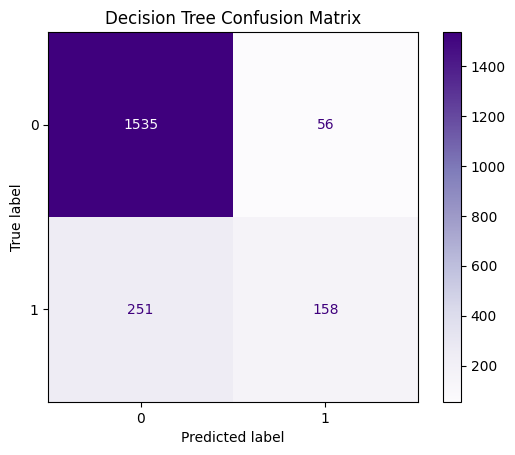

In [56]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap=plt.cm.Purples)
plt.title("Decision Tree Confusion Matrix")
plt.show()

### Random Forest

In [57]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train_processed,y_train)

y_pred = rf.predict(X_test_processed)

In [58]:
print("confusion_matrix")
print(confusion_matrix(y_test,y_pred))
print("classification Report")
print(classification_report(y_test,y_pred))

confusion_matrix
[[1523   68]
 [ 219  190]]
classification Report
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1591
           1       0.74      0.46      0.57       409

    accuracy                           0.86      2000
   macro avg       0.81      0.71      0.74      2000
weighted avg       0.85      0.86      0.84      2000



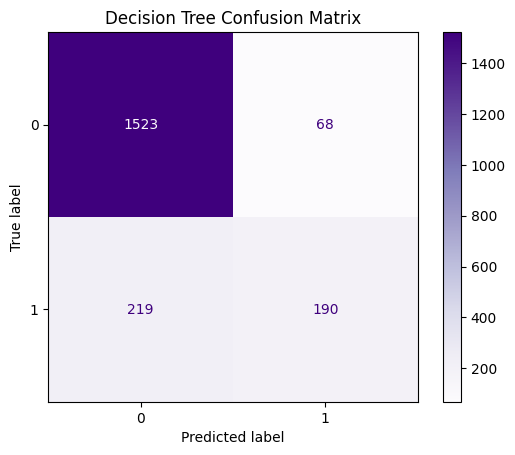

In [59]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap=plt.cm.Purples)
plt.title("Decision Tree Confusion Matrix")
plt.show()

### XGBoost

In [60]:
from xgboost import XGBClassifier

xgb= XGBClassifier(n_estimators=100, learning_rate=0.1, use_label_encoder=False, eval_metric='logloss', random_state=42)

xgb.fit(X_train_processed,y_train)

y_pred = xgb.predict(X_test_processed)

e:\MY_Projects\Churn_Modelling\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:46:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [61]:
print("confusion_matrix")
print(confusion_matrix(y_test,y_pred))
print("classification Report")
print(classification_report(y_test,y_pred))

confusion_matrix
[[1520   71]
 [ 207  202]]
classification Report
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1591
           1       0.74      0.49      0.59       409

    accuracy                           0.86      2000
   macro avg       0.81      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000



In [62]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

# تدريب
lgb_model.fit(X_train_processed, y_train)

# توقعات
y_pred = lgb_model.predict(X_test_processed)
y_proba = lgb_model.predict_proba(X_test_processed)[:,1]

[LightGBM] [Info] Number of positive: 1628, number of negative: 6368
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000114 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 859
[LightGBM] [Info] Number of data points in the train set: 7996, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203602 -> initscore=-1.363933
[LightGBM] [Info] Start training from score -1.363933


In [63]:
# تقييم
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)

print("LightGBM Metrics:")
print(f"Accuracy: {acc:.4f}, F1 Score: {f1:.4f}, ROC-AUC: {roc:.4f}")

LightGBM Metrics:
Accuracy: 0.8565, F1 Score: 0.5847, ROC-AUC: 0.8568


In [64]:
print("confusion_matrix")
print(confusion_matrix(y_test,y_pred))
print("classification Report")
print(classification_report(y_test,y_pred))

confusion_matrix
[[1511   80]
 [ 207  202]]
classification Report
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      1591
           1       0.72      0.49      0.58       409

    accuracy                           0.86      2000
   macro avg       0.80      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000



In [65]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42, verbose=0)

# تدريب
cat_model.fit(X_train_processed, y_train)

# توقعات
y_pred = cat_model.predict(X_test_processed)
y_proba = cat_model.predict_proba(X_test_processed)[:,1]

In [66]:
# تقييم
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)

print("CatBoost Metrics:")
print(f"Accuracy: {acc:.4f}, F1 Score: {f1:.4f}, ROC-AUC: {roc:.4f}")

CatBoost Metrics:
Accuracy: 0.8550, F1 Score: 0.5659, ROC-AUC: 0.8658


In [67]:
print("confusion_matrix")
print(confusion_matrix(y_test,y_pred))
print("classification Report")
print(classification_report(y_test,y_pred))

confusion_matrix
[[1521   70]
 [ 220  189]]
classification Report
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1591
           1       0.73      0.46      0.57       409

    accuracy                           0.85      2000
   macro avg       0.80      0.71      0.74      2000
weighted avg       0.84      0.85      0.84      2000



In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

results = []

models = {
    "Logistic Regression": lr_model,
    "K-Nearest Neighbors": knn,
    "Support Vector Machine": svm,
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost": xgb,
    "LightGBM": lgb_model,
    "CatBoost": cat_model
}

for name, model in models.items():
    y_pred = model.predict(X_test_processed)
    y_proba = model.predict_proba(X_test_processed)[:,1]
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1 Score": f1,
        "ROC-AUC": roc
    })

results_df = pd.DataFrame(results)
results_df.set_index("Model", inplace=True)
results_df

,Accuracy,F1 Score,ROC-AUC
Model,,,
Logistic Regression,0.8035,0.281536,0.761157
K-Nearest Neighbors,0.8380,0.509091,0.789983
Support Vector Machine,0.8520,0.514754,0.823451
Decision Tree,0.8465,0.507223,0.837165
Random Forest,0.8565,0.569715,0.846562
XGBoost,0.8610,0.592375,0.860995
LightGBM,0.8565,0.584660,0.856792
CatBoost,0.8550,0.565868,0.865825


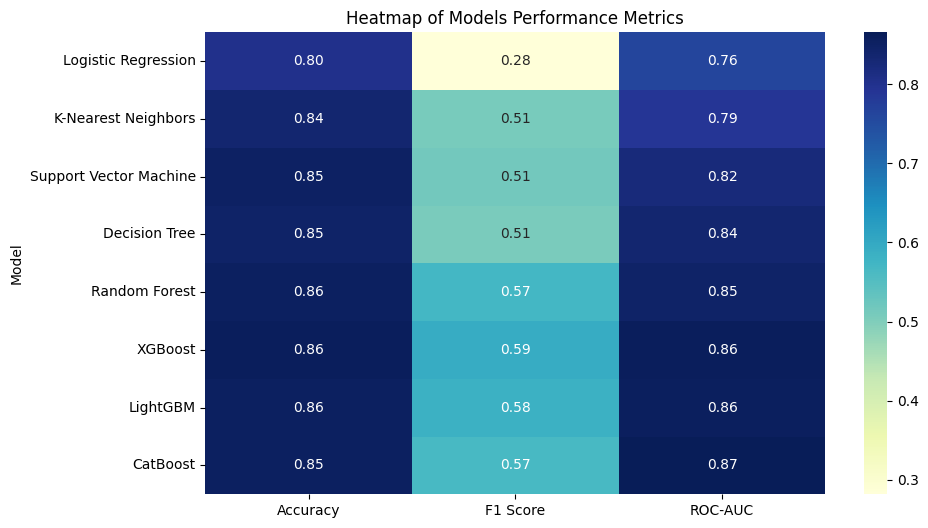

In [69]:
plt.figure(figsize=(10,6))
sns.heatmap(results_df, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Heatmap of Models Performance Metrics")
plt.show()

### Apply SMOTE

In [71]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote , y_train_smote = smote.fit_resample(X_train_processed,y_train)

In [72]:
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

Before SMOTE: Exited
0    6368
1    1628
Name: count, dtype: int64
After SMOTE: Exited
0    6368
1    6368
Name: count, dtype: int64


### Appply XGBoost and Random Forest  with SMOTE

In [74]:
# Random forest 
rf.fit(X_train_smote,y_train_smote)
y_pred = rf.predict(X_test_processed)
y_proba = rf.predict_proba(X_test_processed)[:,1]

In [75]:
acc = accuracy_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
roc = roc_auc_score(y_test,y_proba)

print("RF_smote Metrics")
print(f"Accuracy : {acc:.4f}, F1 : {f1:.4f}, ROC-AUC : {roc:.4f}")

RF_smote Metrics
Accuracy : 0.8475, F1 : 0.6034, ROC-AUC : 0.8534


In [76]:
print("Confusion Matrix")
print(confusion_matrix(y_test,y_pred))
print("Classification Report")
print(classification_report(y_test,y_pred))

Confusion Matrix
[[1463  128]
 [ 177  232]]
Classification Report
              precision    recall  f1-score   support

           0       0.89      0.92      0.91      1591
           1       0.64      0.57      0.60       409

    accuracy                           0.85      2000
   macro avg       0.77      0.74      0.75      2000
weighted avg       0.84      0.85      0.84      2000



In [77]:
# XGBoosting
xgb.fit(X_train_smote,y_train_smote)

y_pred = xgb.predict(X_test_processed)

e:\MY_Projects\Churn_Modelling\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:50:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [78]:
acc = accuracy_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print(f"Accuracy : {acc:.4f}, F1 : {f1:.4f}")

Accuracy : 0.8530, F1 : 0.6192


In [97]:
# === Hyperparameter Tuning for XGBoost (with SMOTE) ===

from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# XGBoost base model
xgb = XGBClassifier(
    random_state=42,
    eval_metric='auc',
    use_label_encoder=False
)

# Parameter grid (focused and efficient)
param_grid = {
    'n_estimators': [300,500],
    'max_depth': [4,6,8],
    'learning_rate': [0.01, 0.05, 0.1],
}

# GridSearch with 3-fold CV (balanced speed/quality)
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1',          # Optimize for churn class F1
    cv=3,
    n_jobs=-1,             # Use all CPU cores
    verbose=1
)

print("Starting GridSearchCV for XGBoost...")
grid_search.fit(X_train_smote, y_train_smote)



Starting GridSearchCV for XGBoost...
Fitting 3 folds for each of 18 candidates, totalling 54 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [4, 6, ...], 'n_estimators': [300, 500]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : 

In [98]:
# Best model details
print("\nBest Parameters:", grid_search.best_params_)
print("Best F1 Score (CV):", round(grid_search.best_score_, 4))


Best Parameters: {'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 300}
Best F1 Score (CV): 0.8675


In [99]:
# Evaluate best model on test set
best_xgb = grid_search.best_estimator_

y_pred = best_xgb.predict(X_test_processed)
y_pred_proba = best_xgb.predict_proba(X_test_processed)[:, 1]

print("\n=== Test Set Performance (Tuned XGBoost + SMOTE) ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_pred_proba):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== Test Set Performance (Tuned XGBoost + SMOTE) ===
Accuracy : 0.8555
F1 Score : 0.6172
ROC-AUC  : 0.8559

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      1591
           1       0.67      0.57      0.62       409

    accuracy                           0.86      2000
   macro avg       0.78      0.75      0.76      2000
weighted avg       0.85      0.86      0.85      2000


Confusion Matrix:
[[1478  113]
 [ 176  233]]
